In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### MAIL.Intervention table

The MAIL schema captures both MAPS and TAMS records of intervention with 44,363 and 17,185 records in the former and latter, respectively, in the past FY (evident from the count of values 
"M" and "T" in the [Source system code] column, not show below).

In [2]:
mail_int_df = pd.read_csv("./Mail_Intervention.csv", parse_dates=['Intervention date'])

mail_int_df.sample(5)

,Intervention GUID,Record number,Intervention date,Intervening officer GUID,Mail gateway facility GUID,Mail detector dog SK,Mail screening channel SK,Is survey,Mail class SK,Mail gateway facility SK,Country of origin code,Mail pathway SK,Article summary SK
61360,3d3223b7-7553-42b5-a239-ff3d070cbb2f,VM24000791,2024-02-12,NaN,09ccf300-05c2-11d4-840a-0060b06ad3cb,126.0,7.0,0,3,2.0,CN,4.0,6
5819,95d933df-df6a-4fb9-a465-180b6000e30e,NM23023014,2023-08-25,67c9057c-d4aa-ea11-a814-000d3a6a9def,334fc9ec-0601-11d4-840a-0060b06ad3cb,354.0,7.0,0,3,1.0,CN,4.0,6
46902,6a2f3608-276d-413a-b255-c251441f6884,VM23008723,2023-12-29,NaN,09ccf300-05c2-11d4-840a-0060b06ad3cb,0.0,2.0,0,1,2.0,FR,6.0,6
36947,28e83b8f-205d-4df7-90c8-98afa48155bf,ART-0000011649-24O,2024-05-29,6aba5cca-14ee-ec11-bb3d-000d3acc256b,7006ecae-2a42-ee11-bdf4-00224892212f,NaN,5.0,1,4,2.0,GB,5.0,2
43429,79afdaa5-41c7-4a9b-b382-b3be6bc0fa80,NM24004493,2024-02-10,NaN,334fc9ec-0601-11d4-840a-0060b06ad3cb,292.0,7.0,0,3,1.0,CN,4.0,6


There are no interventions shared between MAPS and TAMS:

In [3]:
mail_int_df['Intervention GUID'].nunique()

61548

Supplementing the Mail Class SK codes with the values from Mail.RefClass:

In [4]:
mail_int_df['Mail class'] = mail_int_df['Mail class SK'].map({1: "EMS",
                                                              2: "Letters",
                                                              3: "OAs",
                                                              4: "OAs mixed",
                                                              5: "OAs small",
                                                              6: "OAs large",
                                                              7: "Parcels"})

Similarly, supplementing the Mail gateway facility SK codes with the values with those from Mail.RefGateway:

In [5]:
mail_int_df['Mail gateway facility'] = mail_int_df['Mail gateway facility SK'].map({1: "NSW",
                                                                                    2: "VIC",
                                                                                    3: "QLD",
                                                                                    4: "WA"})

Finally, the Mail screening channel SK codes being supplemented with the values from Mail.ScreeningChannel:

In [6]:
mail_int_df['Mail screening channel'] = mail_int_df['Mail screening channel SK'].map({2: "2D X-Ray",
                                                                                      3: "3D X-Ray",
                                                                                      8: "Border force",
                                                                                      7: "Detector dog",
                                                                                      10: "Dual",
                                                                                      6: "Inspection",
                                                                                      9: "Manual",
                                                                                      1: "Not recorded",
                                                                                      4: "Officer intuitive",
                                                                                      5: "Survey"})

Mail interventions by the day of week indicate, as expected, that vast majority of intervention take place in Sydney and Melbourne, while in the weekends seem non-working: 

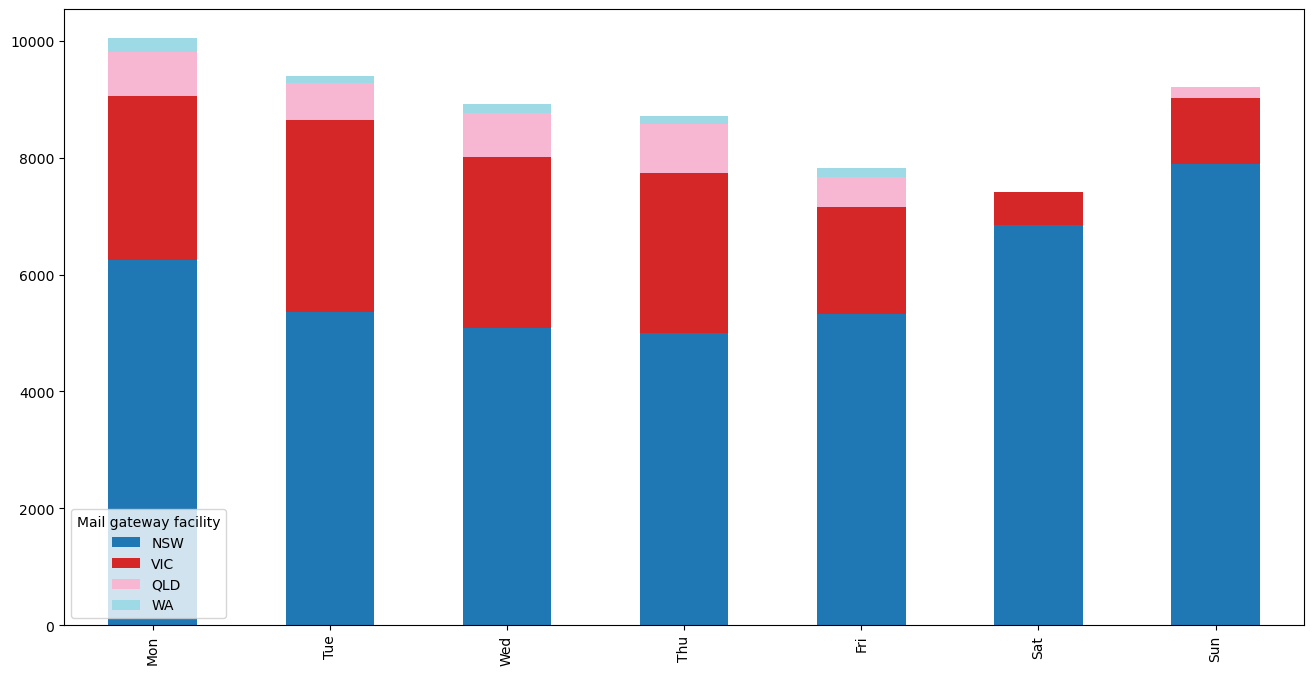

In [7]:
mail_int_df.groupby(['Mail gateway facility', pd.to_datetime(mail_int_df['Intervention date']).dt.weekday])\
    ['Intervention GUID'].count().unstack().fillna(0).astype("int").\
    rename_axis(columns={"Intervention date": ""}).\
    rename(columns={0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}).sort_values(by='Mon', ascending=False).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20");

Mail interventions by the month, over the course of 2023/24 financial year, show a sudden pick up in interventions from May 2024 on, while in Perth the activity stopped in Nov 2023:

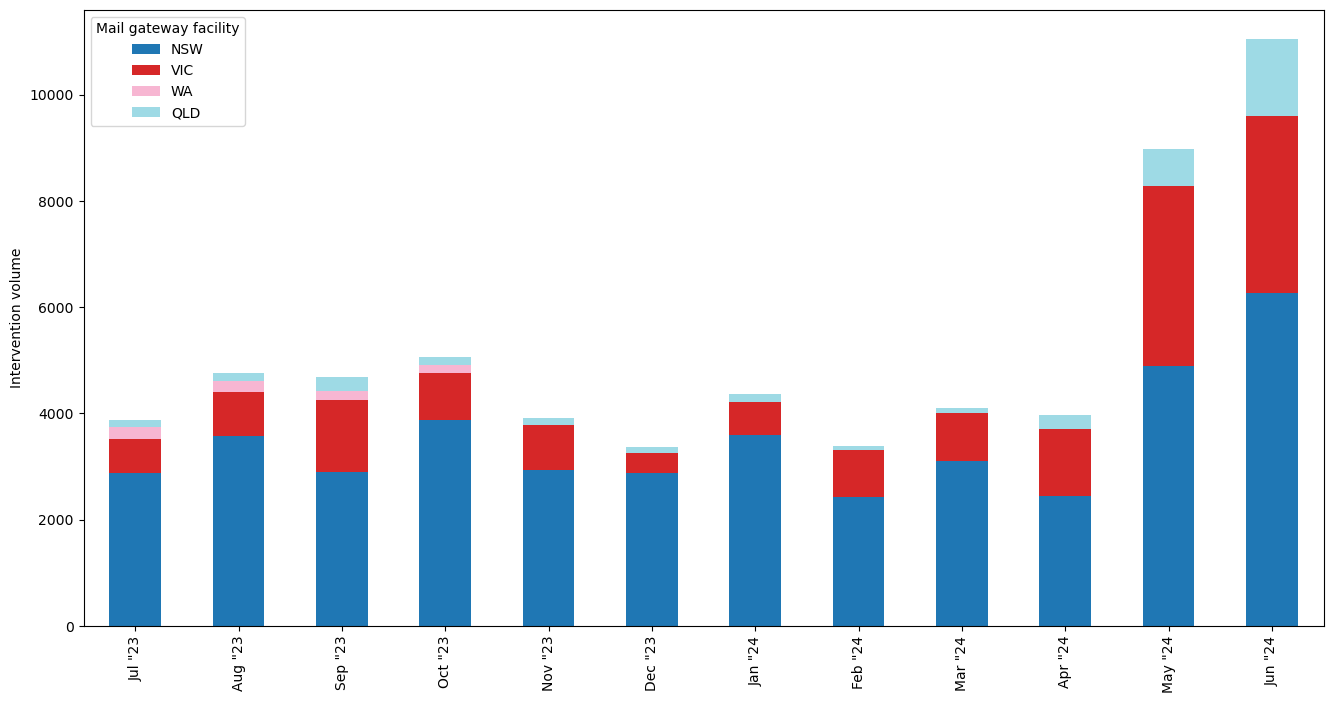

In [8]:
mail_int_df.groupby(['Mail gateway facility', pd.to_datetime(mail_int_df['Intervention date']).dt.month])\
    ['Intervention GUID'].count().unstack().fillna(0).astype("int").\
    rename_axis(columns={"Intervention date": ""})[[7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6]].\
    rename(columns={7: 'Jul "23', 8: 'Aug "23', 9: 'Sep "23', 10: 'Oct "23', 11: 'Nov "23', 12: 'Dec "23', 1: 'Jan "24', 2: 'Feb "24', 3: 'Mar "24', 4: 'Apr "24', 5: 'May "24', 6: 'Jun "24'}).\
    sort_values(by='Jul "23', ascending=False).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20", ylabel="Intervention volume");

The activity pick up appears to have arisen due to increased interest in Parcels, EMS and other articles (OAs) mixed and small:

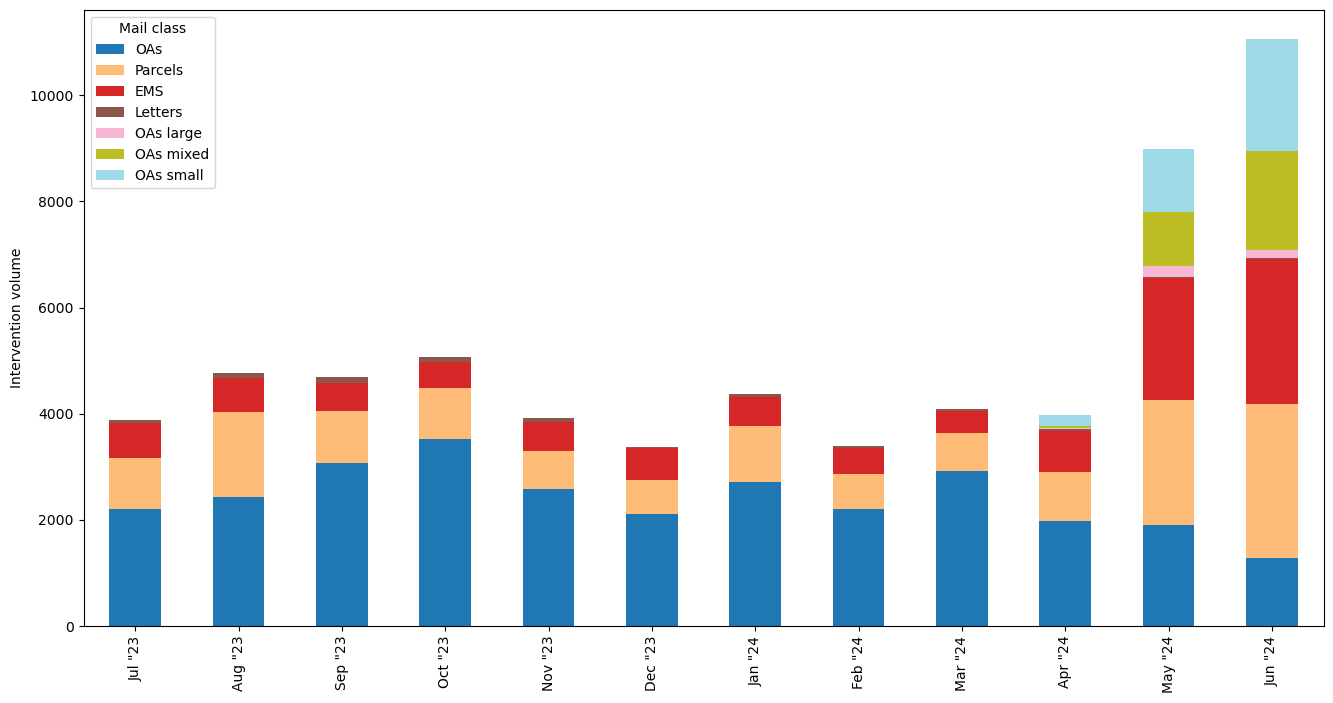

In [9]:
mail_int_df.groupby(['Mail class', pd.to_datetime(mail_int_df['Intervention date']).dt.month])\
    ['Intervention GUID'].count().unstack().fillna(0).astype("int").\
    rename_axis(columns={"Intervention date": ""})[[7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6]].\
    rename(columns={7: 'Jul "23', 8: 'Aug "23', 9: 'Sep "23', 10: 'Oct "23', 11: 'Nov "23', 12: 'Dec "23', 1: 'Jan "24', 2: 'Feb "24', 3: 'Mar "24', 4: 'Apr "24', 5: 'May "24', 6: 'Jun "24'}).\
    sort_values(by='Jul "23', ascending=False).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20", ylabel="Intervention volume");

Interventions including EMS, mixed and small OA feature rather prominent in Melbourne, whereas Sydney handles the vast majority of Letters, Parcels and unspecified OAs:

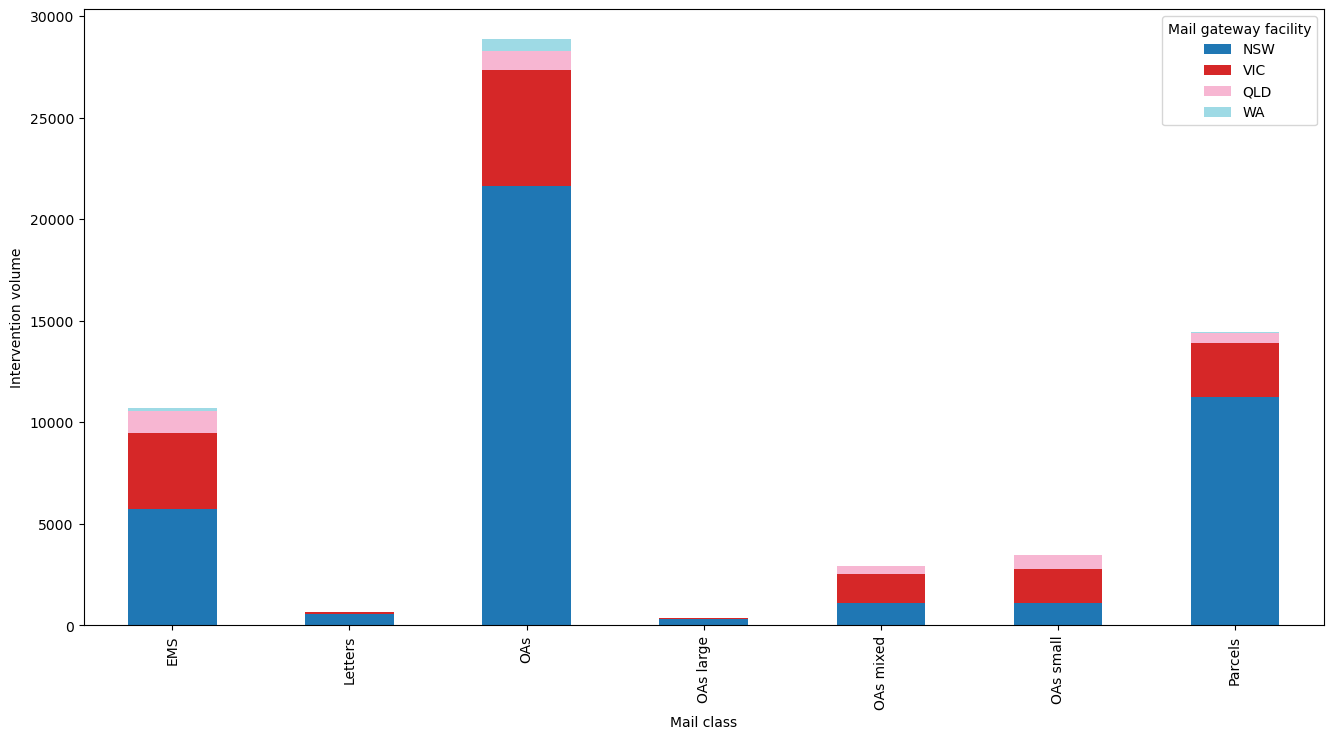

In [10]:
mail_int_df.pivot_table(values='Intervention GUID', columns='Mail class', index='Mail gateway facility', aggfunc="count", margins=False)\
.sort_values(by='EMS', ascending=False).T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20", ylabel="Intervention volume");

At the end of the FY the Survey and 3D X-ray interventions suddenly ramped up, with an increase in 2D X-ray too, but with slight drop in the use of Detector Dogs:

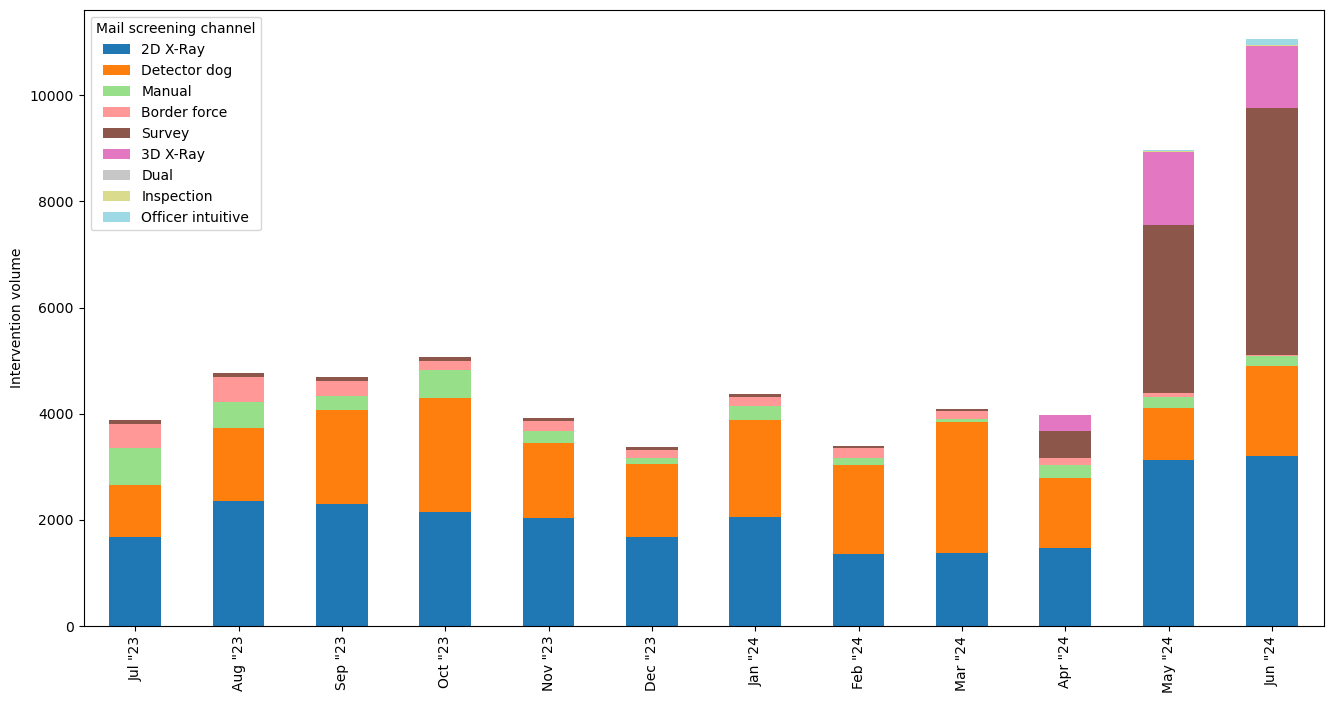

In [11]:
mail_int_df.groupby(['Mail screening channel', pd.to_datetime(mail_int_df['Intervention date']).dt.month])\
    ['Intervention GUID'].count().unstack().fillna(0).astype("int").\
    rename_axis(columns={"Intervention date": ""})[[7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6]].\
    rename(columns={7: 'Jul "23', 8: 'Aug "23', 9: 'Sep "23', 10: 'Oct "23', 11: 'Nov "23', 12: 'Dec "23', 1: 'Jan "24', 2: 'Feb "24', 3: 'Mar "24', 4: 'Apr "24', 5: 'May "24', 6: 'Jun "24'}).\
    sort_values(by='Jul "23', ascending=False).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20", ylabel="Intervention volume");

Detector dog is the dominant channel for unspecified OAs, while for the rest of OAs the Survey prevails. 2D X-ray is the key screening channel for EMS and Parcels with, which less frequently can undergo 3D X-ray screening: 

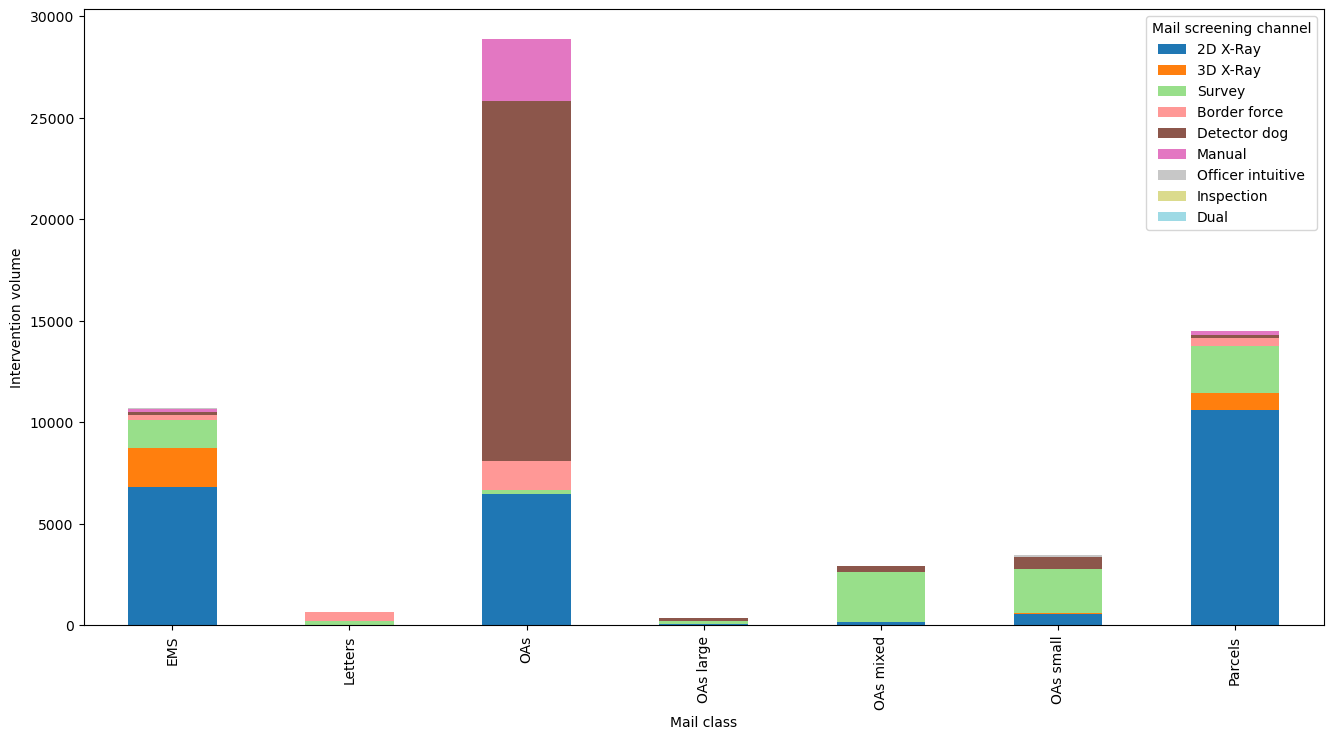

In [12]:
mail_int_df.pivot_table(values='Intervention GUID', columns='Mail class', index='Mail screening channel', aggfunc="count", margins=False)\
.sort_values(by='EMS', ascending=False).T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20", ylabel="Intervention volume");

Interestingly, 3D X-ray interventions have been carried out mostly in Melbourne. Also notworthy is that Detector Dogs have been used only in Sydney and Melbourne:

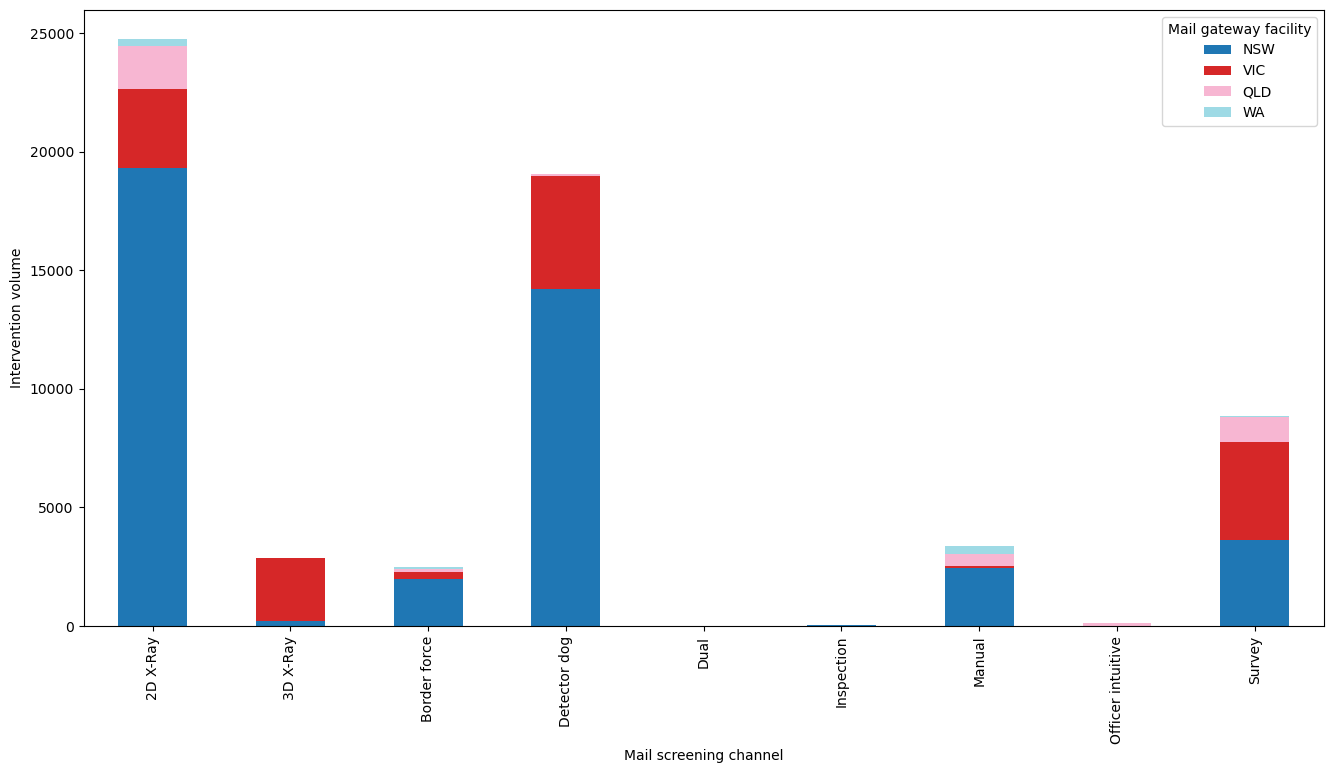

In [13]:
mail_int_df.pivot_table(values='Intervention GUID', columns='Mail screening channel', index='Mail gateway facility', aggfunc="count", margins=False)\
.sort_values(by='2D X-Ray', ascending=False).T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20", ylabel="Intervention volume");

The total intervention volume of each screening channel:

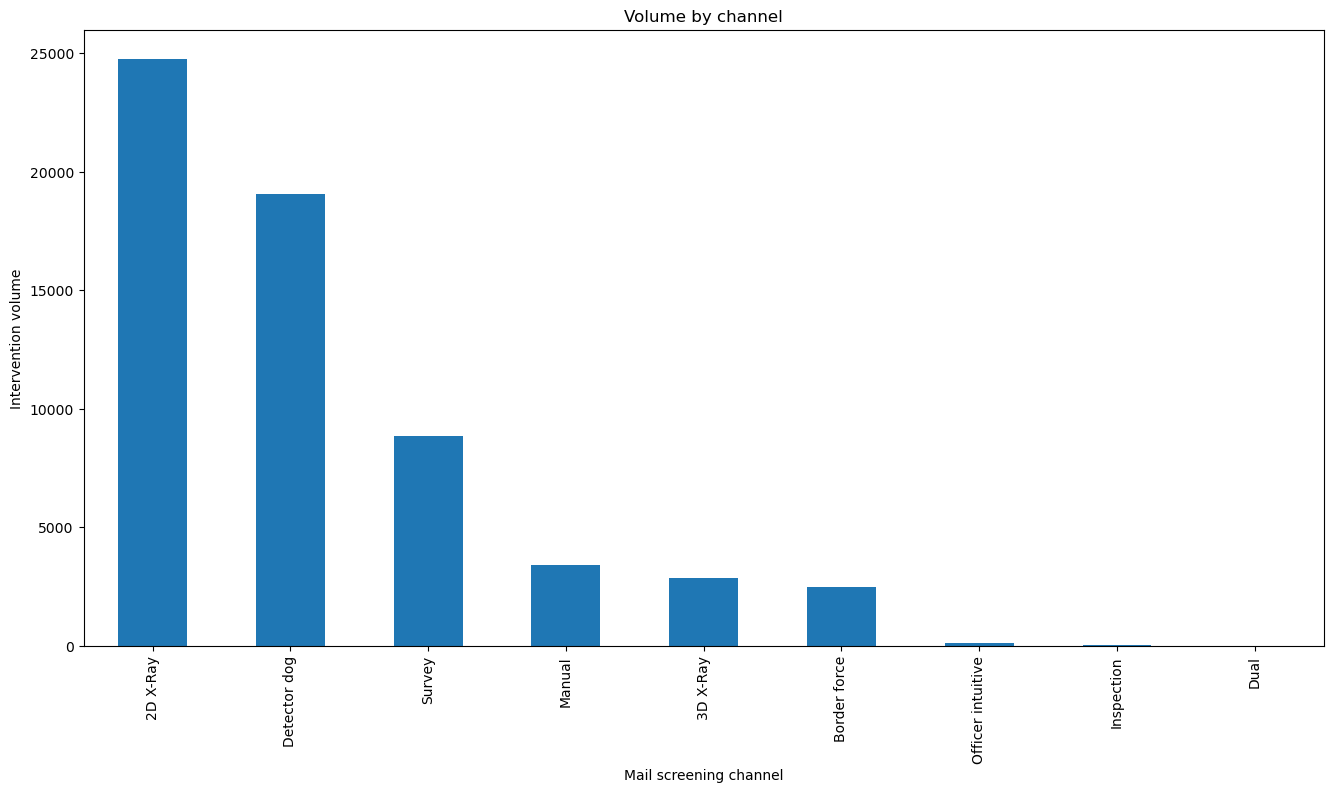

In [14]:
mail_int_df['Mail screening channel'].value_counts().plot.bar(title='Volume by channel', figsize=(16, 8))
plt.ylabel("Intervention volume")
plt.xticks(rotation='vertical');

#### MAPS.MailArticle table

Now comparing the data above with that from the MAPS.MailArticle table over the same time period (i.e., the financial year 2023/24):

In [15]:
maps_art_df = pd.read_csv("./MAPS_MailArticle.csv", parse_dates=['Intervention date'])

maps_art_df.sample(5)

,Article GUID,Intervention date,Article ID,Mail class ID,Mail gateway facility GUID,Declared value,Is whole parcel interception,Is part parcel interception,Country of origin GUID,Intervening officer GUID,Detector dog handler GUID,Detector dog ID
20568,62ddd85f-c3ad-4923-b373-76e913d634f2,2024-06-01,NM24013893,3,334fc9ec-0601-11d4-840a-0060b06ad3cb,10.0,1,0,034d0207-38b1-11d3-9d7d-0060b0eb252b,40d02fd3-6783-4ea1-830d-5625e4f5e15c,00000000-0000-0000-0000-000000000000,0
38121,acbb8e56-4428-4222-b1ae-dbff7f981f7d,2024-02-18,NM24005068,3,334fc9ec-0601-11d4-840a-0060b06ad3cb,7.0,1,0,034d0050-38b1-11d3-9d7d-0060b0eb252b,c3b93d74-9ae0-11d6-bc1d-00a0c9a72cf0,a801428c-3a72-4305-a411-c939a58a1886,365
22948,33ead70a-42fa-45be-aed3-844ffcd8dc4a,2023-08-08,NM23020721,1,334fc9ec-0601-11d4-840a-0060b06ad3cb,NaN,0,1,034d0230-38b1-11d3-9d7d-0060b0eb252b,e1d47189-83df-11d6-bc13-00a0c9a72cf0,00000000-0000-0000-0000-000000000000,0
30722,216bbb79-3b8e-4528-a854-b141923e8149,2023-12-12,NM23034523,3,334fc9ec-0601-11d4-840a-0060b06ad3cb,NaN,0,1,034d0092-38b1-11d3-9d7d-0060b0eb252b,5b56e604-491c-4d32-9bcd-d25e2c989094,5b56e604-491c-4d32-9bcd-d25e2c989094,376
1192,d3fc76cb-a38f-4616-86cb-07107b2bbb38,2023-12-16,NM23034905,3,334fc9ec-0601-11d4-840a-0060b06ad3cb,NaN,1,0,034d0191-38b1-11d3-9d7d-0060b0eb252b,ca5d3f32-e313-4ec8-bc20-7c21de79f808,5b56e604-491c-4d32-9bcd-d25e2c989094,376


In [16]:
maps_art_df['Mail class ID'] = maps_art_df['Mail class ID'].map({1: "EMS",
                                                               2: "Letters",
                                                               3: "OAs",
                                                               4: "Parcels"})

In [17]:
maps_art_df['Intervention date'].describe()

count                            44363
mean     2023-12-08 06:09:01.911052288
min                2023-07-01 00:00:00
25%                2023-09-15 00:00:00
50%                2023-11-29 00:00:00
75%                2024-02-28 00:00:00
max                2024-06-30 00:00:00
Name: Intervention date, dtype: object

Mail interventions by the month, over the course of 2023/24 financial year:

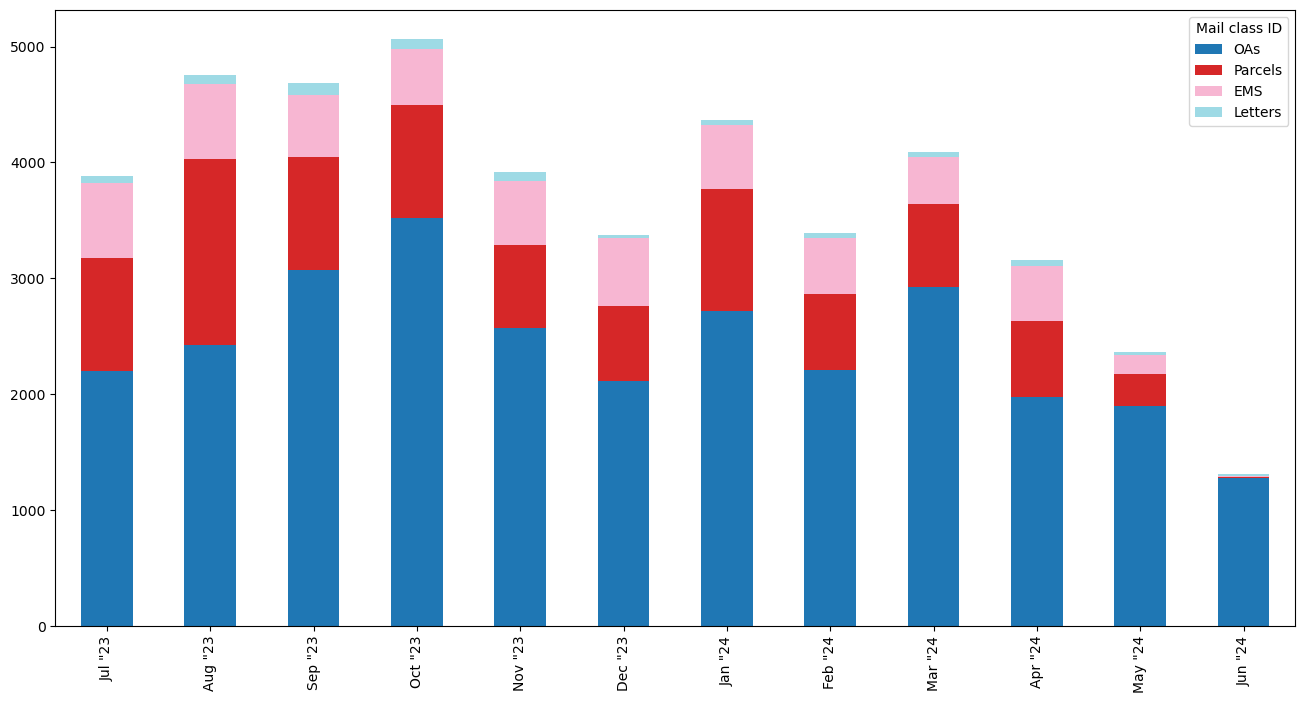

In [18]:
maps_art_df.groupby(['Mail class ID', pd.to_datetime(maps_art_df['Intervention date']).dt.month])\
    ['Article GUID'].count().unstack().fillna(0).astype("int").\
    rename_axis(columns={"Intervention date": ""})[[7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6]].\
    rename(columns={7: 'Jul "23', 8: 'Aug "23', 9: 'Sep "23', 10: 'Oct "23', 11: 'Nov "23', 12: 'Dec "23', 1: 'Jan "24', 2: 'Feb "24', 3: 'Mar "24', 4: 'Apr "24', 5: 'May "24', 6: 'Jun "24'}).\
    sort_values(by='Jul "23', ascending=False).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20");

#### MAPS.Interception table

In [19]:
maps_intercept_df = pd.read_csv("./MAPS_Interception.csv", parse_dates=['Inspection date'])

maps_intercept_df.sample(5)

,Interception ID,Inspection date,Mail interception type code,Is whole parcel interception,Is part parcel interception,Detector dog interception type code,Is declarant,Entry method ID,Country of origin ID,Action officer ID,Detector dog handler ID,Detector dog ID,Mail class ID,Inspection location ID,Record number
20052,2fc976cc-963f-41e9-9487-7a05b652935d,2023-09-20,WP,1,0,H,0,2,034d0233-38b1-11d3-9d7d-0060b0eb252b,1fcdfc19-6812-4a37-9e9e-47b99e03a96a,5b56e604-491c-4d32-9bcd-d25e2c989094,376,3,334fc9ec-0601-11d4-840a-0060b06ad3cb,NM23025380
37696,0e4c7d37-1372-4037-98f5-bfc5af620e43,2024-05-01,WP,1,0,NaN,0,2,034d0247-38b1-11d3-9d7d-0060b0eb252b,c0bfcbb6-93db-11d6-bc19-00a0c9a72cf0,00000000-0000-0000-0000-000000000000,0,3,d606db3a-41a2-11d4-849e-0060b0eb2549,QM24000655
43844,bcb65e1a-af5e-4067-a2c4-dc0481ac2b53,2024-01-13,WP,1,0,NaN,0,2,034d0050-38b1-11d3-9d7d-0060b0eb252b,534fc0f9-6216-4055-945e-0a487288c0d5,00000000-0000-0000-0000-000000000000,0,3,334fc9ec-0601-11d4-840a-0060b06ad3cb,NM24001517
26877,723e60fa-a7e7-4032-8846-92427df52221,2023-08-20,WP,1,0,NaN,0,2,034d0050-38b1-11d3-9d7d-0060b0eb252b,26fed0df-81d7-4d29-b497-3c05a0d71aea,00000000-0000-0000-0000-000000000000,0,3,334fc9ec-0601-11d4-840a-0060b06ad3cb,NM23022362
27498,d3e3c7df-fe80-4702-8868-934e242b7fc6,2024-02-18,WP,1,0,H,0,2,034d0050-38b1-11d3-9d7d-0060b0eb252b,5c7eb8cd-ea95-4ef0-a25c-2bbc169ba4ec,e1b8712b-d850-4163-96d7-f093cbfecb9b,334,3,334fc9ec-0601-11d4-840a-0060b06ad3cb,NM24005105


In [20]:
maps_intercept_df['Mail class ID'] = maps_intercept_df['Mail class ID'].map({1: "EMS",
                                                               2: "Letters",
                                                               3: "OAs",
                                                               4: "Parcels"})

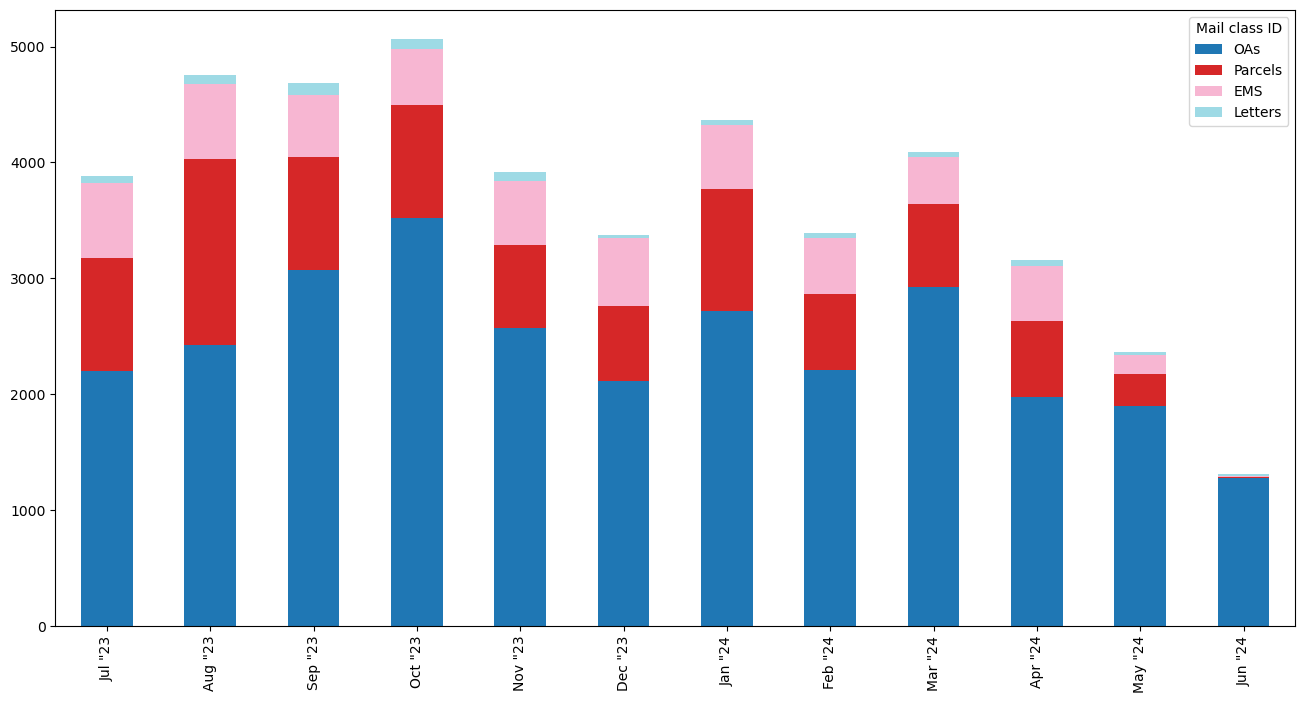

In [21]:
maps_intercept_df.groupby(['Mail class ID', pd.to_datetime(maps_intercept_df['Inspection date']).dt.month])\
    ['Interception ID'].count().unstack().fillna(0).astype("int").\
    rename_axis(columns={"Inspection date": ""})[[7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6]].\
    rename(columns={7: 'Jul "23', 8: 'Aug "23', 9: 'Sep "23', 10: 'Oct "23', 11: 'Nov "23', 12: 'Dec "23', 1: 'Jan "24', 2: 'Feb "24', 3: 'Mar "24', 4: 'Apr "24', 5: 'May "24', 6: 'Jun "24'}).\
    sort_values(by='Jul "23', ascending=False).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20");

#### TAMS.MailArticle table

Finally, there has been a move awat from the MAPS towards TAMS, starting in 2024:

In [22]:
tams_art_df = pd.read_csv("./TAMS_MailArticle.csv", parse_dates=['Intervention date'])

tams_art_df.sample(5)

,Article GUID,Record number,Intervention date,Article status code,Intervening officer GUID,Article inspection description,Country of origin GUID,Article scanned datetime,Detector dog GUID,Mail class ID,Mail gateway facility GUID,Is re-present to detector dog
273,f1e8626b-7ef3-4265-937b-03e716b2ee58,ART-0000003709-24O,2024-05-09,293050000,a13d032a-57ec-ec11-bb3d-000d3acc2a2f,watch and sunglasses,cf9bb0d8-2bdd-ea11-a817-000d3a799df1,2024-05-09 23:42:00.0000000,NaN,293050002,7006ecae-2a42-ee11-bdf4-00224892212f,0
4744,68ec89ef-8089-4b54-b680-44ac05795c7d,ART-0000004759-24E,2024-05-15,293050000,2c312b01-d6aa-ea11-a814-000d3a6a9def,metal bar,ae9ab0d8-2bdd-ea11-a817-000d3a799df1,2024-05-15 23:39:00.0000000,NaN,293050000,7006ecae-2a42-ee11-bdf4-00224892212f,0
5947,daa41c74-08ed-47fc-b901-56162785f5e0,ART-0000018362-24O,2024-06-11,293050000,486f0687-d0aa-ea11-a814-000d3a6a9c0e,rubber gloves,a69ab0d8-2bdd-ea11-a817-000d3a799df1,2024-06-11 02:45:00.0000000,NaN,293050005,7e344ae1-2a42-ee11-bdf4-00224892212f,0
5475,6342a4d6-2a82-418d-8aab-4ee3e482742a,ART-0000010273-24P,2024-05-27,293050000,ff2f6e93-d0aa-ea11-a814-000d3a6a9c0e,NaN,b79bb0d8-2bdd-ea11-a817-000d3a799df1,2024-05-27 08:27:00.0000000,NaN,293050001,7e344ae1-2a42-ee11-bdf4-00224892212f,0
13346,c3afc78e-00c5-4490-a3b1-c46491385769,ART-0000016602-24P,2024-06-07,293050002,aa4c7ea0-d4aa-ea11-a814-000d3a6a9def,NaN,c99bb0d8-2bdd-ea11-a817-000d3a799df1,2024-06-07 01:56:00.0000000,NaN,293050001,7e344ae1-2a42-ee11-bdf4-00224892212f,0


In [23]:
tams_art_df['Intervention date'].describe()

count                            17185
mean     2024-06-03 04:40:27.512365312
min                2024-03-05 00:00:00
25%                2024-05-22 00:00:00
50%                2024-06-04 00:00:00
75%                2024-06-19 00:00:00
max                2024-06-30 00:00:00
Name: Intervention date, dtype: object

Mail interventions by the month, over the course of 2023/24 financial year, shows that TAMS only began in Mar 2024.

In [24]:
tams_art_df['Mail class ID'] = tams_art_df['Mail class ID'].map({293050000: "EMS",
                                                                 293050001: "Parcel",
                                                                 293050002: "OA-Mixed",
                                                                 293050003: "OA-Small",
                                                                 293050004: "Letter",
                                                                 293050005: "OA-Large"})

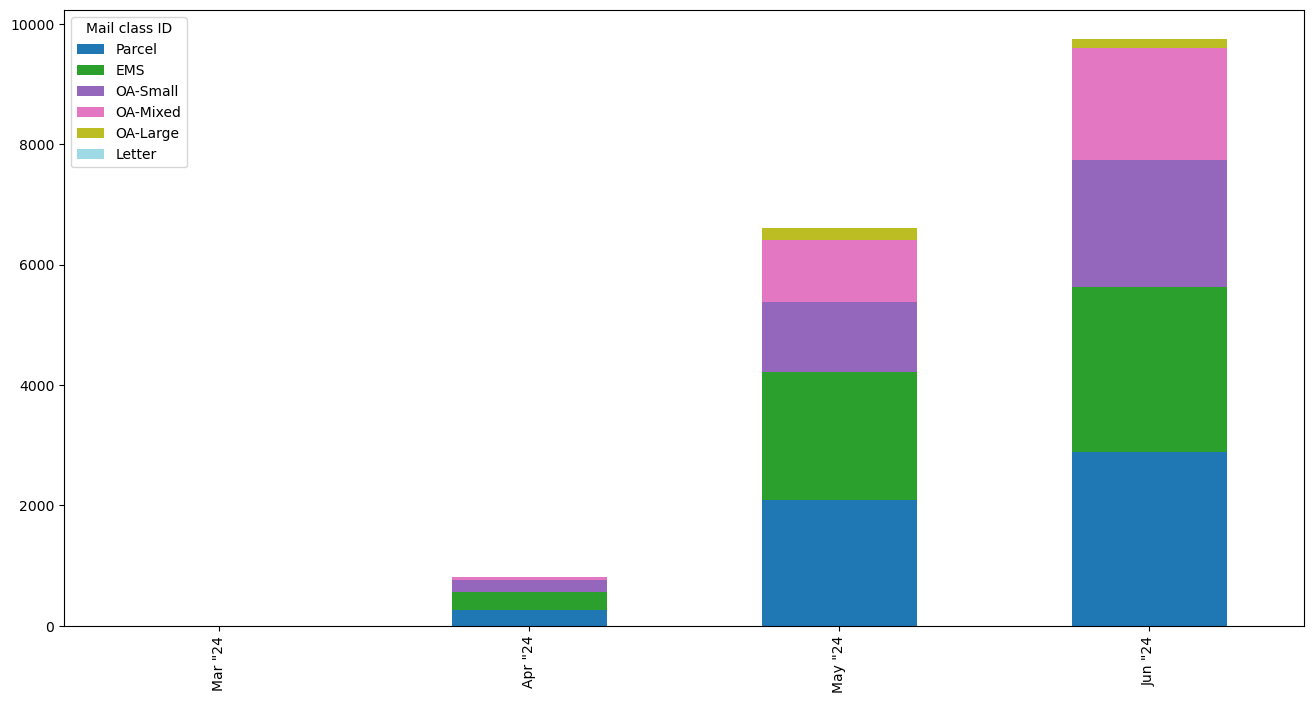

In [25]:
tams_art_df.groupby(['Mail class ID', pd.to_datetime(tams_art_df['Intervention date']).dt.month])\
    ['Article GUID'].count().unstack().fillna(0).astype("int").\
    rename_axis(columns={"Intervention date": ""}).\
    rename(columns={3: 'Mar "24', 4: 'Apr "24', 5: 'May "24', 6: 'Jun "24'}).\
    sort_values(by='Jun "24', ascending=False).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20");

#### T3MAIL.InterventionVolume table

In [26]:
t3_ivol_df = pd.read_csv("./T3MAIL_InterventionVolume.csv", parse_dates=['Statistic date'])

t3_ivol_df.sample(5)

,Statistic entry ID,Statistic date,Mail class SK,Mail gateway facility SK,Value,Statistic activity ID,Mail pathway SK
4232,692937,2024-01-01,1,3,28,335,6
2901,690702,2023-10-01,1,2,2602,347,4
5639,695948,2024-04-01,3,2,1,338,4
1853,689141,2023-08-01,1,4,3,335,6
1453,688494,2023-07-01,3,2,1,353,-1


In [27]:
act_type = pd.read_csv("./Mail_RefInterventionActivityType.csv")
act_type

,Statistic activity ID,Is volume,Is survey,Is intervention,Is inspection,Is x-ray,Is detector dog,Statistic activity description,Statistic sub-type,Mail pathway SK,Mail screening channel SK
0,333,0,1,0,0,0,0,Assessed & Released Total Samples,Mail Survey Stats,1,1
1,334,0,1,1,0,0,0,Manual Inspect Total Samples,Mail Survey Stats,5,6
2,335,0,1,1,0,1,0,X-ray Only Total Samples,Mail Survey Stats,6,2
3,336,0,1,1,0,1,0,X-ray + Inspect Total Samples,Mail Survey Stats,6,6
4,337,0,1,1,0,0,1,K9 Only Total Samples,Mail Survey Stats,4,7
5,338,0,1,1,0,0,1,K9 + Inspect Total Samples,Mail Survey Stats,4,6
6,339,0,1,1,0,0,0,Dual Screened Only Total Samples,Mail Survey Stats,3,10
7,340,0,1,1,0,0,0,Dual Screened + Inspect Total Samples,Mail Survey Stats,3,6
8,341,0,1,0,0,0,0,Border Force Only Total Samples,Mail Survey Stats,2,8
9,342,0,1,0,0,0,0,Border Force + Inspect Total Samples,Mail Survey Stats,2,6


In [28]:
t3_ivol_df = t3_ivol_df.assign(is_volume=t3_ivol_df['Statistic activity ID'].ge(343).astype(np.uint8))

In [29]:
t3_ivol_df = t3_ivol_df.assign(is_intervention=t3_ivol_df['Statistic activity ID'].isin([334, 335, 336, 337, 338, 339, 340, 344, 345, 346, 347, 348, 349, 350, 352]).astype(np.uint8))

In [30]:
t3_ivol_df = t3_ivol_df.assign(is_inspection=t3_ivol_df['Statistic activity ID'].isin([344, 346, 348, 350, 352]).astype(np.uint8))

In [31]:
t3_ivol_df = t3_ivol_df.assign(is_xray=t3_ivol_df['Statistic activity ID'].isin([335, 336, 345, 346]).astype(np.uint8))

In [32]:
t3_ivol_df = t3_ivol_df.assign(is_dog=t3_ivol_df['Statistic activity ID'].isin([337, 338, 347, 348]).astype(np.uint8))

In [33]:
t3_ivol_df.sample(5)

,Statistic entry ID,Statistic date,Mail class SK,Mail gateway facility SK,Value,Statistic activity ID,Mail pathway SK,is_volume,is_intervention,is_inspection,is_xray,is_dog
4097,692699,2023-12-01,3,2,2,337,4,0,1,0,0,1
690,687509,2023-06-01,3,1,1,335,6,0,1,0,1,0
4079,692681,2023-12-01,7,2,0,337,4,0,1,0,0,1
4342,693221,2024-01-01,3,2,1,342,2,0,0,0,0,0
3415,691606,2024-01-01,1,1,0,335,6,0,1,0,1,0


In [34]:
t3_ivol_df.groupby('is_volume')['Value'].sum()

is_volume
0     2809582
1    35893260
Name: Value, dtype: int64

In [35]:
t3_ivol_df.groupby('is_intervention')['Value'].sum()

is_intervention
0    27057593
1    11645249
Name: Value, dtype: int64

In [36]:
t3_ivol_df.groupby('is_inspection')['Value'].sum()

is_inspection
0    38565821
1      137021
Name: Value, dtype: int64

In [37]:
t3_ivol_df.groupby('is_xray')['Value'].sum()

is_xray
0    33723051
1     4979791
Name: Value, dtype: int64

In [38]:
t3_ivol_df.groupby('is_dog')['Value'].sum()

is_dog
0    32074797
1     6628045
Name: Value, dtype: int64

In [39]:
t3_ivol_df['Mail class SK'].value_counts()

Mail class SK
3    2090
7    1778
1    1648
2     134
Name: count, dtype: int64

In [40]:
t3_ivol_df['Mail gateway facility SK'].value_counts()

Mail gateway facility SK
1    2909
2    1477
3     744
4     520
Name: count, dtype: int64

In [41]:
t3_ivol_df['Mail pathway SK'].value_counts()

Mail pathway SK
 6    3204
 4    1393
 2     292
 5     281
-1     266
 1     208
 3       6
Name: count, dtype: int64

In [42]:
t3_ivol_df.query('`Mail pathway SK`.lt(0)').describe()

,Statistic entry ID,Statistic date,Mail class SK,Mail gateway facility SK,Value,Statistic activity ID,Mail pathway SK,is_volume,is_intervention,is_inspection,is_xray,is_dog
count,266.000000,266,266.000000,266.000000,266.000000,266.000000,266.0,266.0,266.0,266.0,266.0,266.0
mean,690996.484962,2023-10-08 07:18:29.774436096,3.530075,1.909774,12.552632,354.093985,-1.0,1.0,0.0,0.0,0.0,0.0
min,686595.000000,2023-05-01 00:00:00,1.000000,1.000000,0.000000,353.000000,-1.0,1.0,0.0,0.0,0.0,0.0
25%,688492.250000,2023-07-01 00:00:00,1.000000,1.000000,2.000000,353.000000,-1.0,1.0,0.0,0.0,0.0,0.0
50%,690851.500000,2023-10-01 00:00:00,3.000000,2.000000,3.000000,354.000000,-1.0,1.0,0.0,0.0,0.0,0.0
75%,693372.750000,2024-01-01 00:00:00,7.000000,3.000000,8.000000,355.000000,-1.0,1.0,0.0,0.0,0.0,0.0
max,695872.000000,2024-04-01 00:00:00,7.000000,3.000000,277.000000,355.000000,-1.0,1.0,0.0,0.0,0.0,0.0
std,2775.548799,NaN,2.446607,0.805253,30.911179,0.797757,0.0,0.0,0.0,0.0,0.0,0.0


Imputing Mail pathway based on the Mail_RefPathwayMap.csv table:

In [43]:
t3_ivol_df['Mail pathway'] = t3_ivol_df['Mail pathway SK'].map({2: "Border force",
                                                                3: "Dual",
                                                                6: "X-ray",
                                                                1: "Not recorded",
                                                                4: "Detector dog",
                                                                5: "Manual",
                                                                -1: "UNK"})

In [44]:
t3_ivol_df['Mail class'] = t3_ivol_df['Mail class SK'].map({1: "EMS",
                                                            2: "Letters",
                                                            3: "OAs",
                                                            7: "Parcels"})

In [45]:
t3_ivol_df['Mail gateway facility'] = t3_ivol_df['Mail gateway facility SK' ].map({1: "NSW",
                                                                                   2: "VIC",
                                                                                   3: "QLD",
                                                                                   4: "WA"})

In [46]:
t3_ivol_df.sample(10)

,Statistic entry ID,Statistic date,Mail class SK,Mail gateway facility SK,Value,Statistic activity ID,Mail pathway SK,is_volume,is_intervention,is_inspection,is_xray,is_dog,Mail pathway,Mail class,Mail gateway facility
3588,691795,2023-11-01,3,2,15,355,-1,1,0,0,0,0,UNK,OAs,VIC
5146,694714,2024-03-01,3,2,1,342,2,0,0,0,0,0,Border force,OAs,VIC
2250,689628,2023-09-01,3,1,5,335,6,0,1,0,1,0,X-ray,OAs,NSW
977,687842,2023-06-01,3,2,16,335,6,0,1,0,1,0,X-ray,OAs,VIC
5024,694460,2024-03-01,3,1,18,337,4,0,1,0,0,1,Detector dog,OAs,NSW
740,687605,2023-06-01,3,3,2,335,6,0,1,0,1,0,X-ray,OAs,QLD
4752,693933,2024-02-01,3,1,0,336,6,0,1,0,1,0,X-ray,OAs,NSW
3582,691789,2023-11-01,3,2,4,344,5,1,1,1,0,0,Manual,OAs,VIC
186,686770,2023-05-01,3,1,1,338,4,0,1,0,0,1,Detector dog,OAs,NSW
3802,692189,2023-12-01,7,1,1,336,6,0,1,0,1,0,X-ray,Parcels,NSW


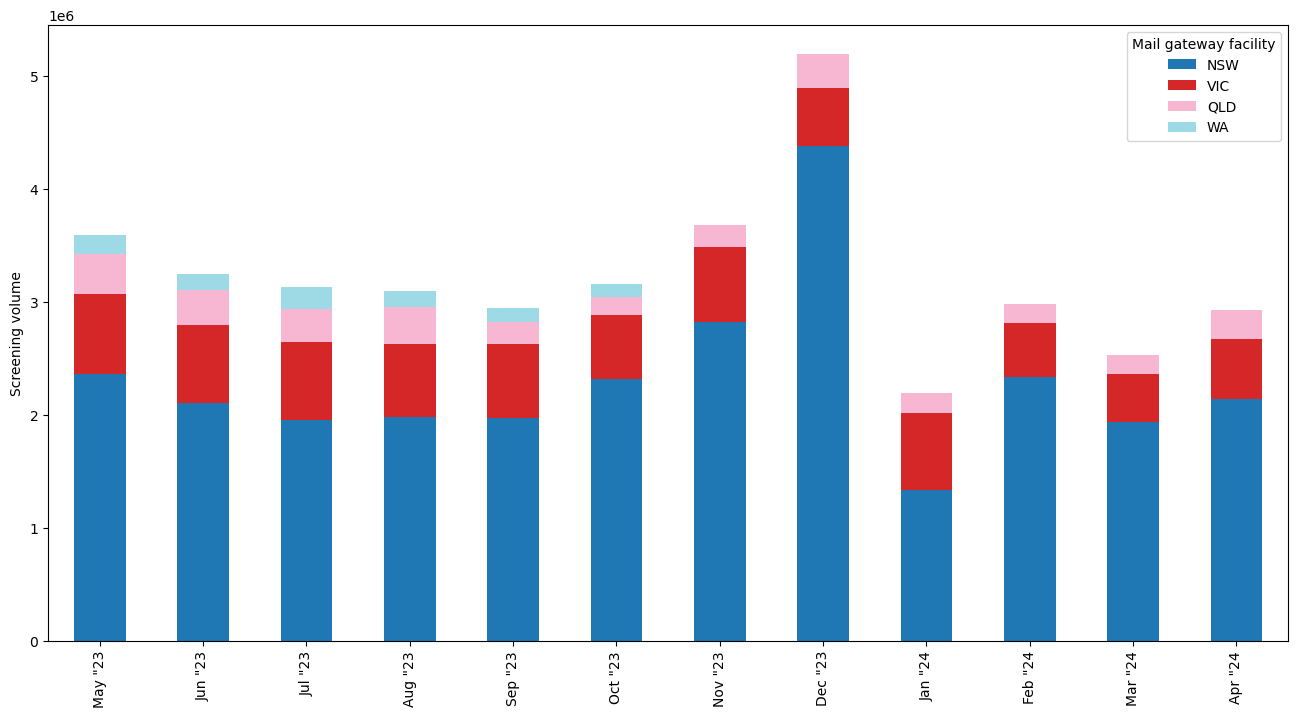

In [47]:
t3_ivol_df.groupby(['Mail gateway facility', pd.to_datetime(t3_ivol_df['Statistic date']).dt.month])\
    ['Value'].sum().unstack().fillna(0).astype("int").\
    rename_axis(columns={"Statistic date": ""})[[5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4]].\
    rename(columns={5: 'May "23', 6: 'Jun "23', 7: 'Jul "23', 8: 'Aug "23', 9: 'Sep "23', 10: 'Oct "23', 11: 'Nov "23', 12: 'Dec "23', 1: 'Jan "24', 2: 'Feb "24', 3: 'Mar "24', 4: 'Apr "24'}).\
    sort_values(by='Jul "23', ascending=False).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20", ylabel="Screening volume");

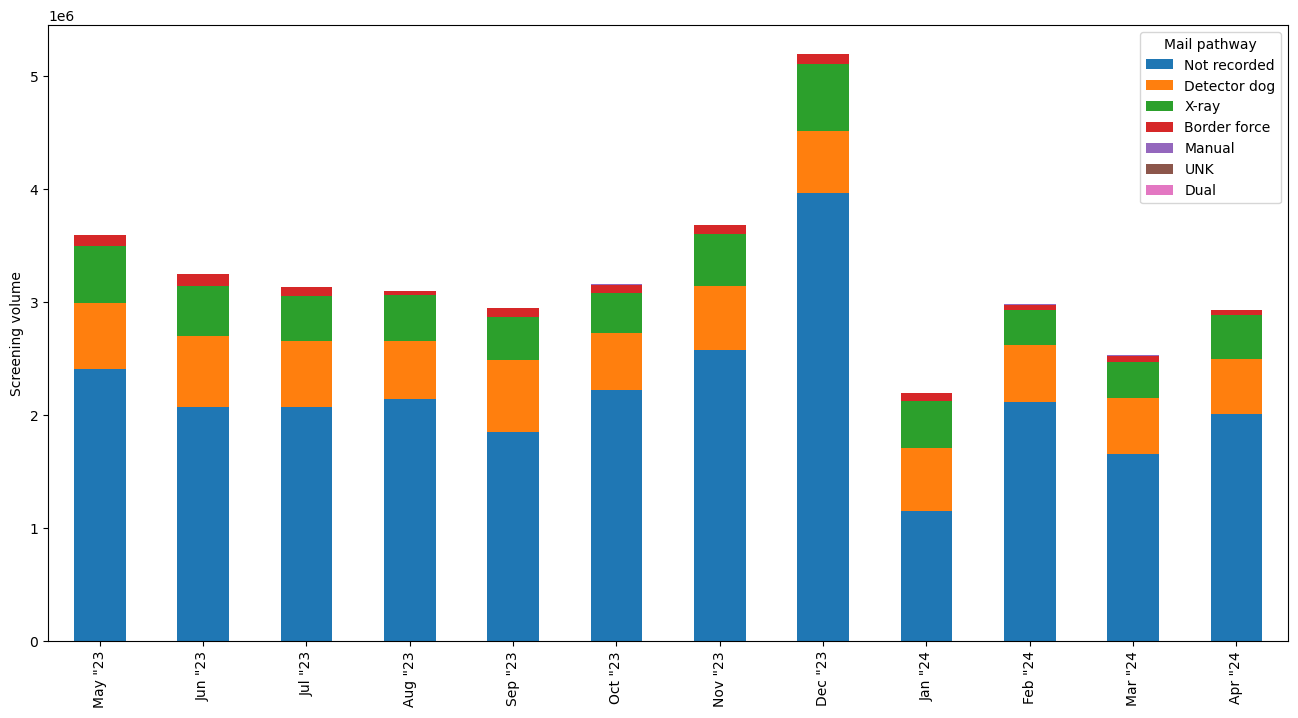

In [48]:
t3_ivol_df.groupby(['Mail pathway', pd.to_datetime(t3_ivol_df['Statistic date']).dt.month])\
    ['Value'].sum().unstack().fillna(0).astype("int").\
    rename_axis(columns={"Statistic date": ""})[[5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4]].\
    rename(columns={5: 'May "23', 6: 'Jun "23', 7: 'Jul "23', 8: 'Aug "23', 9: 'Sep "23', 10: 'Oct "23', 11: 'Nov "23', 12: 'Dec "23', 1: 'Jan "24', 2: 'Feb "24', 3: 'Mar "24', 4: 'Apr "24'}).\
    sort_values(by='Jul "23', ascending=False).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, ylabel="Screening volume");

In [49]:
t3_ivol_df.query('`Mail pathway` in ("UNK", "Manual", "Dual" )')['Value'].sum()

35047

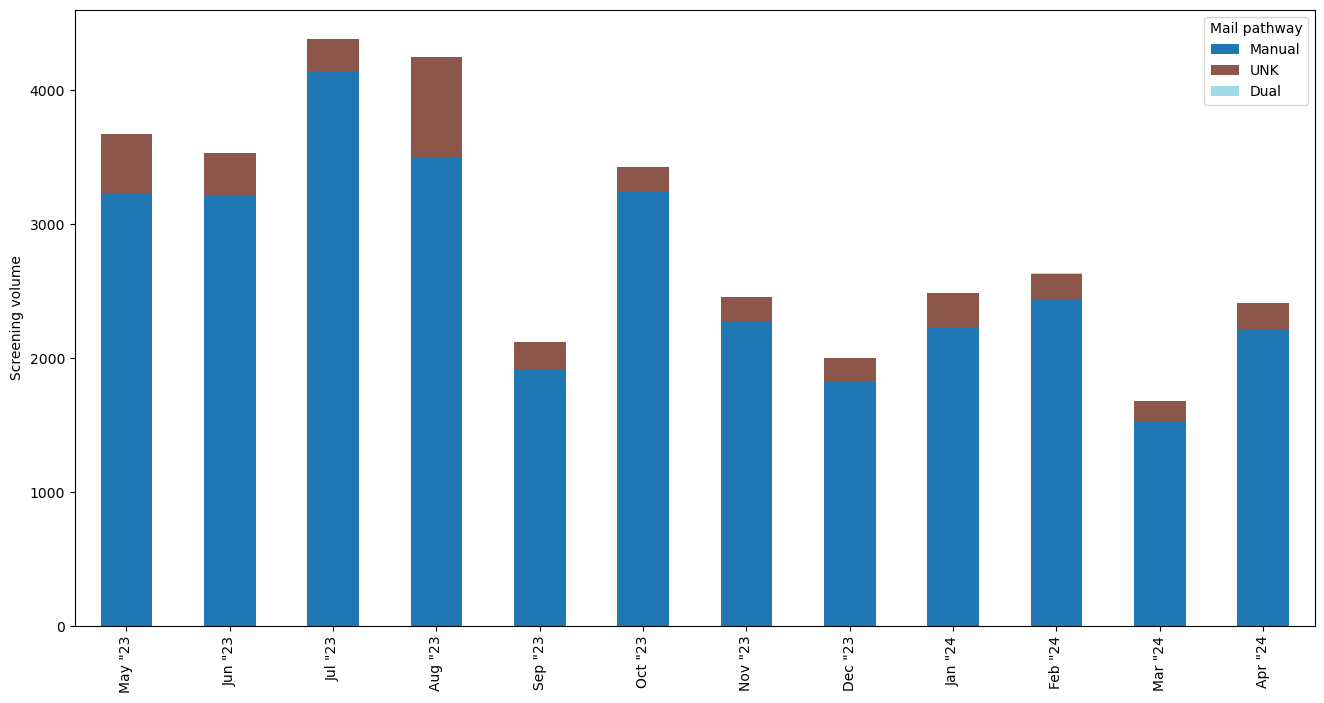

In [50]:
t3_ivol_df.query('`Mail pathway` in ("UNK", "Manual", "Dual" )').groupby(['Mail pathway', pd.to_datetime(t3_ivol_df['Statistic date']).dt.month])\
    ['Value'].sum().unstack().fillna(0).astype("int").\
    rename_axis(columns={"Statistic date": ""})[[5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4]].\
    rename(columns={5: 'May "23', 6: 'Jun "23', 7: 'Jul "23', 8: 'Aug "23', 9: 'Sep "23', 10: 'Oct "23', 11: 'Nov "23', 12: 'Dec "23', 1: 'Jan "24', 2: 'Feb "24', 3: 'Mar "24', 4: 'Apr "24'}).\
    sort_values(by='Jul "23', ascending=False).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, colormap="tab20", ylabel="Screening volume");

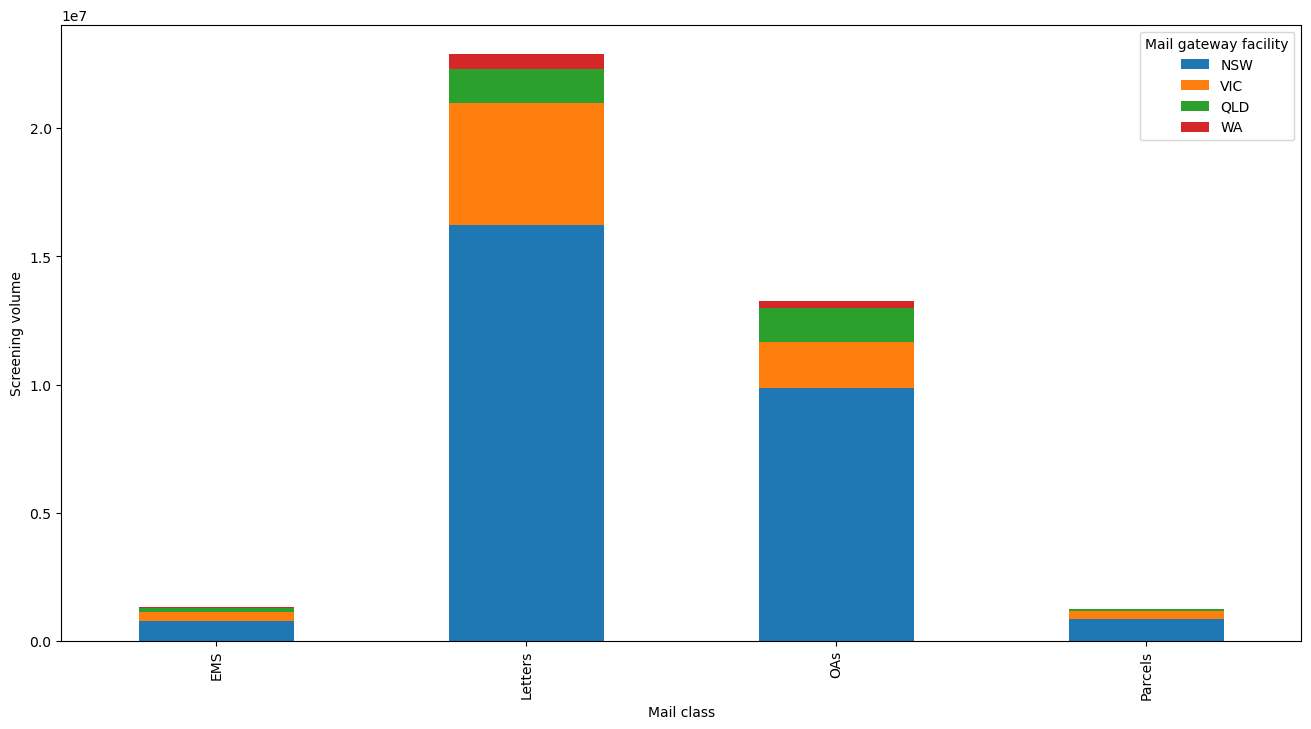

In [51]:
t3_ivol_df.pivot_table(values='Value', columns='Mail class', index='Mail gateway facility', aggfunc="sum", margins=False)\
.sort_values(by='Letters', ascending=False).T.plot(kind="bar", figsize=(16, 8), stacked=True, ylabel="Screening volume");

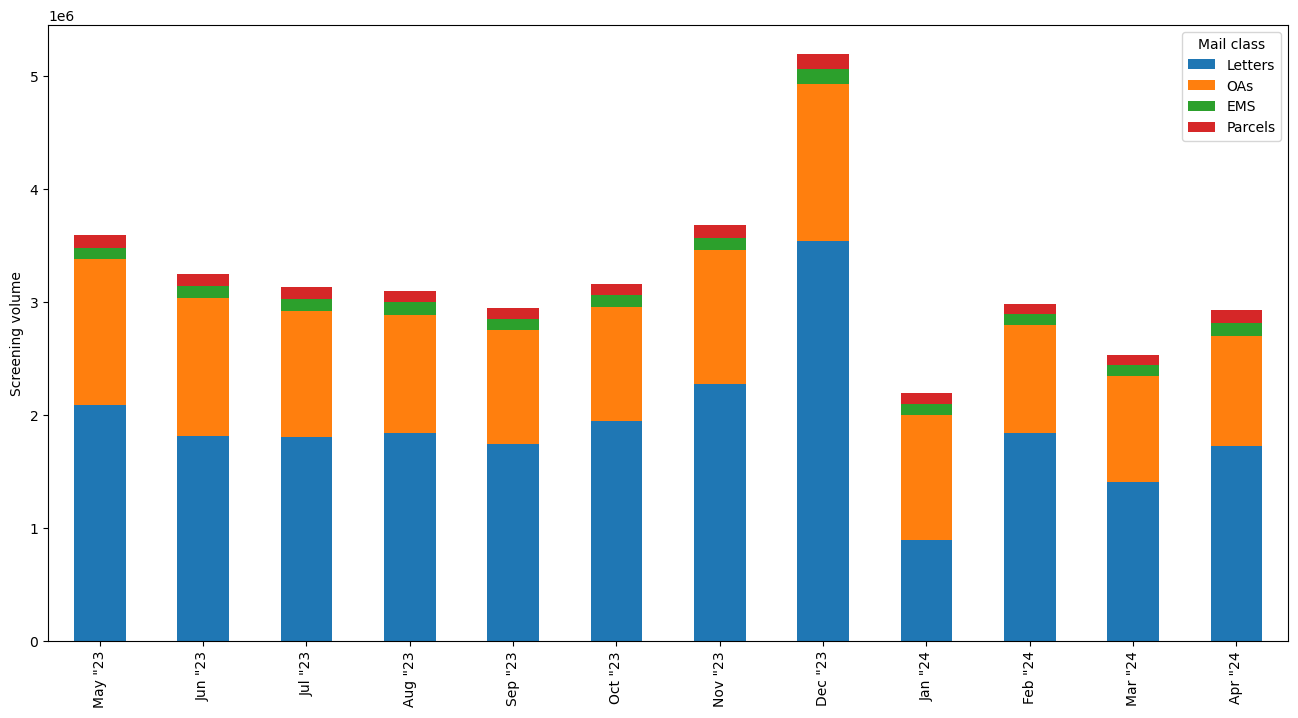

In [52]:
t3_ivol_df.groupby(['Mail class', pd.to_datetime(t3_ivol_df['Statistic date']).dt.month])\
    ['Value'].sum().unstack().fillna(0).astype("int").\
    rename_axis(columns={"Statistic date": ""})[[5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4]].\
    rename(columns={5: 'May "23', 6: 'Jun "23', 7: 'Jul "23', 8: 'Aug "23', 9: 'Sep "23', 10: 'Oct "23', 11: 'Nov "23', 12: 'Dec "23', 1: 'Jan "24', 2: 'Feb "24', 3: 'Mar "24', 4: 'Apr "24'}).\
    sort_values(by='Jul "23', ascending=False).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, ylabel="Screening volume");

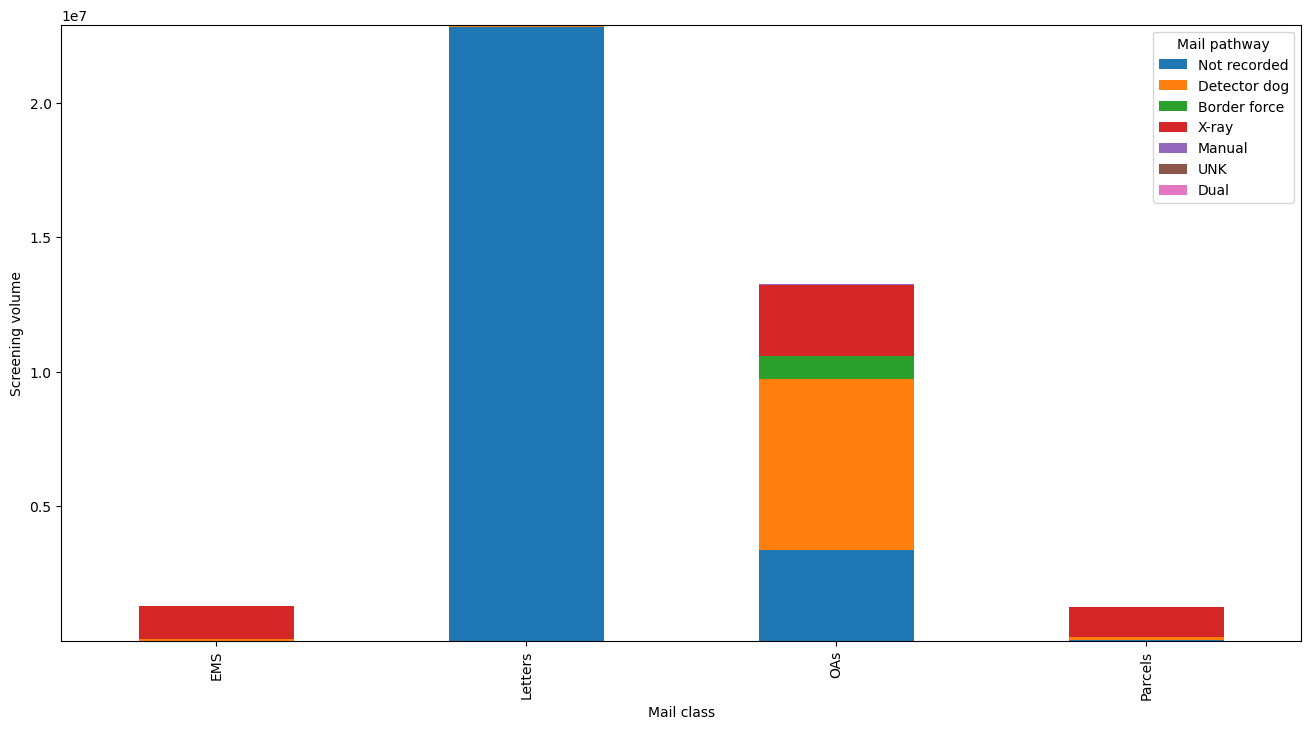

In [53]:
t3_ivol_df.pivot_table(values='Value', columns='Mail class', index='Mail pathway', aggfunc="sum", margins=False)\
.sort_values(by='Letters', ascending=False).T.plot(kind="bar", figsize=(16, 8), stacked=True, ylabel="Screening volume");

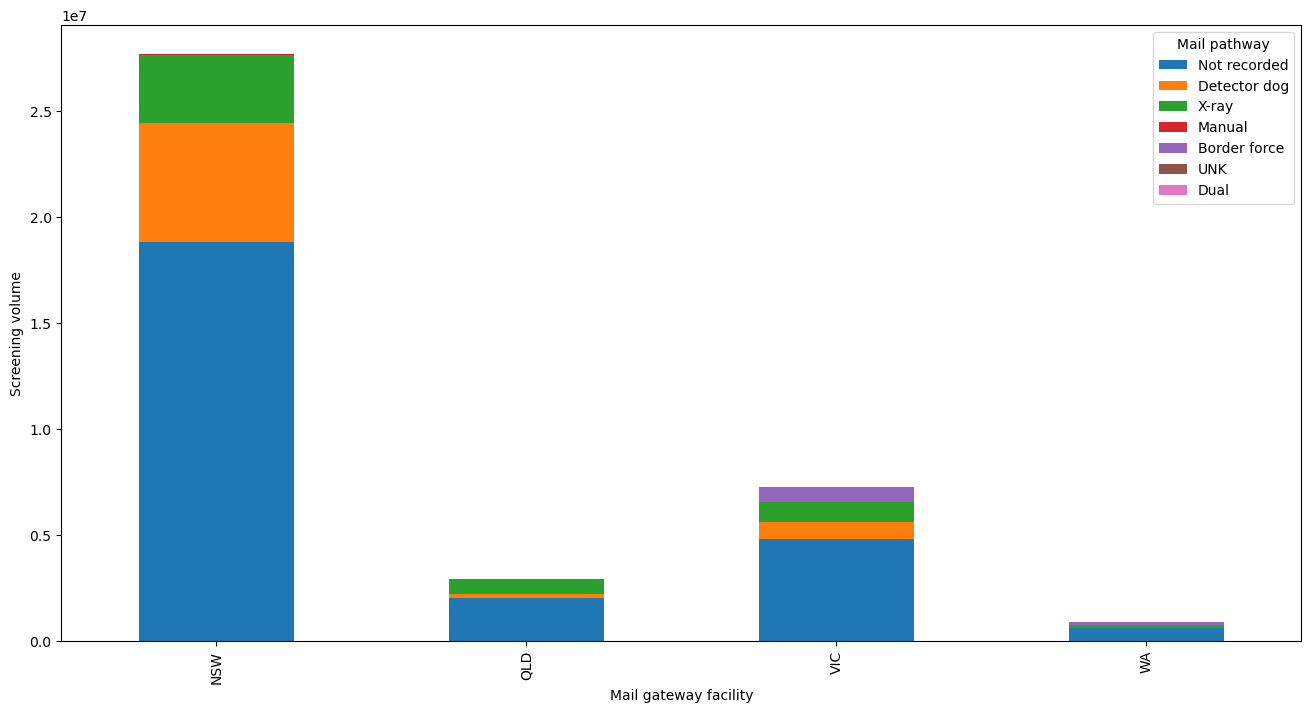

In [54]:
t3_ivol_df.groupby(['Mail pathway', 'Mail gateway facility'])\
    ['Value'].sum().unstack().fillna(0).astype("int").\
    rename_axis(columns={"Mail pathway": ""}).\
    sort_values(by="NSW", ascending=False).\
    T.plot(kind="bar", figsize=(16, 8), stacked=True, ylabel="Screening volume");

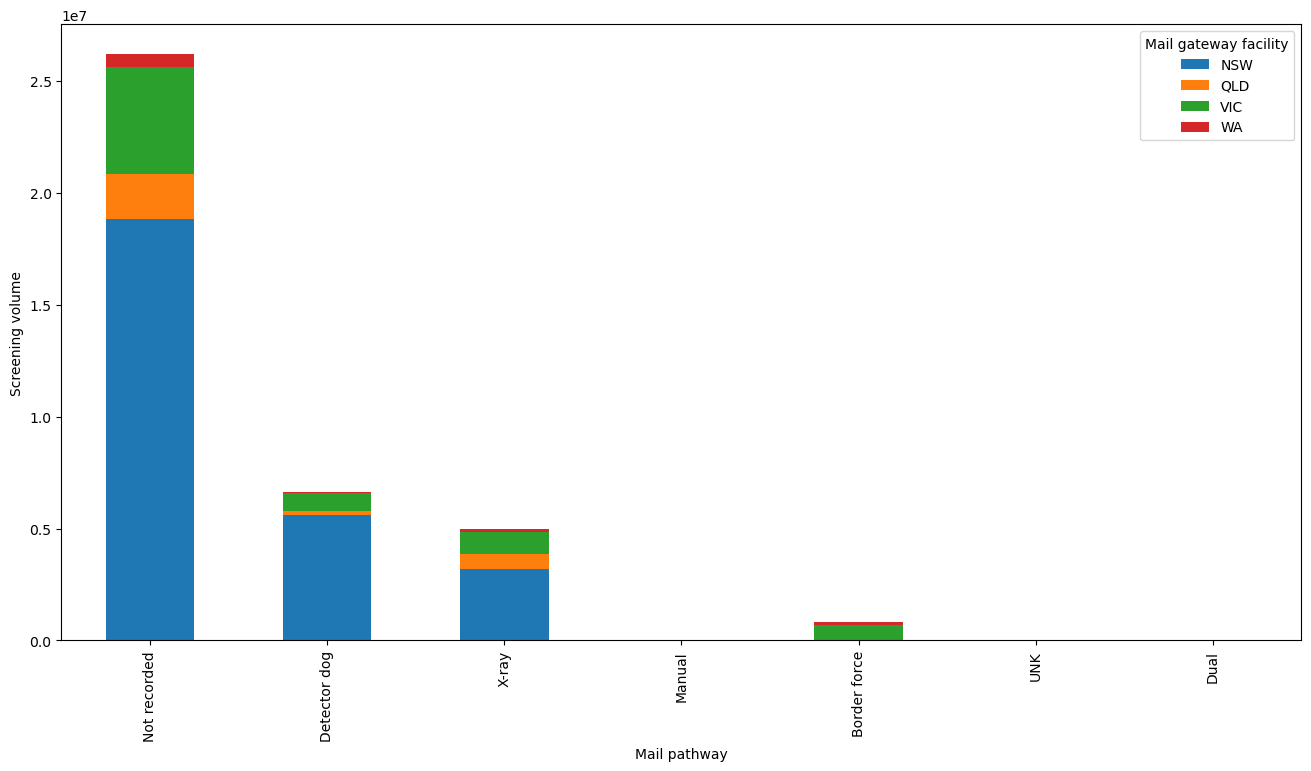

In [55]:
t3_ivol_df.pivot_table(values='Value', index='Mail pathway', columns='Mail gateway facility', aggfunc="sum", margins=False)\
.sort_values(by='NSW', ascending=False).plot(kind="bar", figsize=(16, 8), stacked=True, ylabel="Screening volume");

#### T3MAIL.InterventionResults table

In [56]:
t3_ires_df = pd.read_csv("./T3MAIL_InterventionResult.csv", parse_dates=['Intervention date'])

t3_ires_df.sample(5)

,Intervention GUID,Intervention date,Mail class SK,Mail gateway facility SK,Mail screening channel SK,Mail pathway SK,Intervention item GUID,Item origin country code,Source system code,Article summary SK
44878,30c972a1-d4f2-402a-97d0-9e3020bf890a,2023-07-21,3,2.0,7.0,4.0,19842eca-f596-459c-bf1a-db326f715263,CN,M,6
9351,84c8cc65-89db-495b-ae8c-63a769eb63e9,2024-01-08,7,1.0,2.0,6.0,94c2e2bd-a29d-47fb-8439-2e554093a200,IN,M,6
4134,642a9bac-b714-48e2-9bec-be7c52571e06,2023-10-13,3,1.0,7.0,4.0,0692fe0d-86f2-4cab-8217-1456d8f9bd62,CN,M,6
50833,896e9f1a-5898-40fa-8d56-a20cba87331b,2024-06-04,3,1.0,7.0,4.0,5ac328d0-2139-4d24-93e8-f86d2d02adf6,CN,M,6
15932,38433cad-08ef-4b0c-b7c7-ad4809356f74,2024-03-24,3,1.0,7.0,4.0,08819329-019b-4421-bb75-4ee81a97f565,CN,M,6


All the records from MAPS ("M") have been accounted for the past FY, but of the ~17k TAMS records only ~3K are included:

In [57]:
t3_ires_df['Source system code'].value_counts()

Source system code
M    49304
T     3037
Name: count, dtype: int64